# Graph creation and manipulation in PyVaNe

This notebook shows how to create a graph from a vascular tissue and how to calculate some properties of the vessels.

## Data preparation

Imports, load example image, segment and obtain the skeleton.

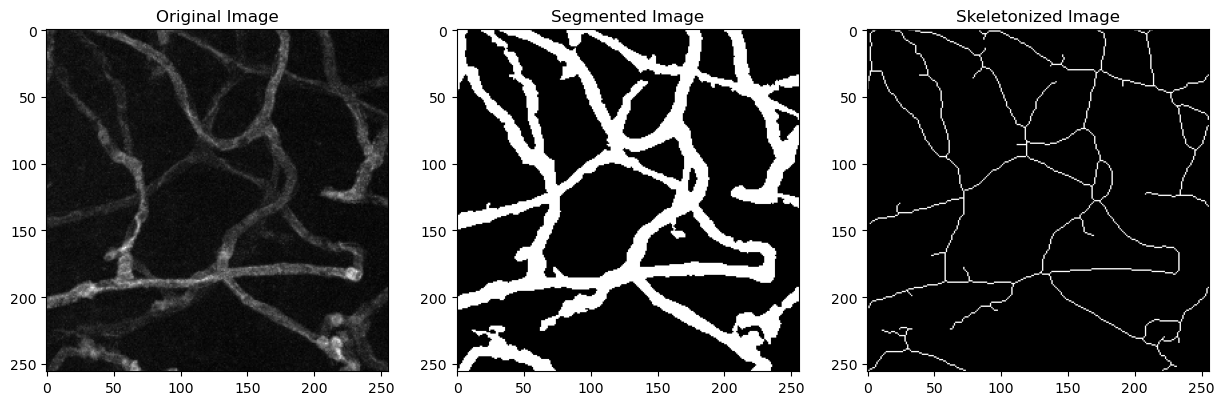

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

from pyvane.graph.creation import create_graph, create_graph_with_mapping
from pyvane.segmentation import local_threshold
from pyvane.skeletonization import lee
from pyvane.util.misc import graph_to_img

file_path = "../data/vessmap_examples/images/12749.tiff"
img = np.array(Image.open(file_path))

bin_img = local_threshold.vessel_segmentation(img, threshold=0, sigma=1, radius=40, comp_size=100, hole_size=30)
skel_img = lee.skeletonize(bin_img)

fig, axs = plt.subplots(1, 3, figsize=(15, 5))
axs[0].imshow(img, cmap="gray")
axs[0].set_title("Original Image")
axs[1].imshow(bin_img, cmap="gray")
axs[1].set_title("Segmented Image")
axs[2].imshow(skel_img, cmap="gray")
axs[2].set_title("Skeletonized Image")
plt.show()

## Graph creation

The function `create_graph` extracts a graph from a binary skeleton image. The function also needs the original binary image to run some heuristics to simplify the graph.

The parameter `length_threshold` sets the scale for artifacts to be removed from the graph. Leaf branches, multiple edges between nodes and self-loops smaller than length_threshold are removed from the graph.

Text(0.5, 1.0, 'Graph Visualization')

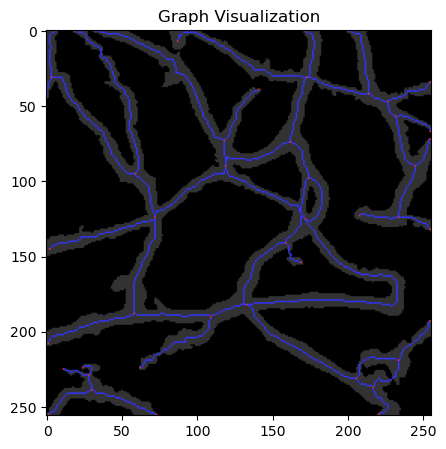

In [2]:
graph = create_graph(skel_img, bin_img, length_threshold=10) 

graph_img = graph_to_img(
    graph, 
    img_shape=img.shape, 
    node_color=(255, 0, 0),
    node_pixels_color=(0, 0, 0), 
    edge_color=(0, 0, 255)
    )

plt.figure(figsize=(5, 5))
plt.imshow(graph_img)
plt.imshow(bin_img, cmap="gray", alpha=0.2)
plt.title("Graph Visualization")

Each node in the graph has the properties:

1. **pixels**: The skeleton pixels that the node represents.
2. **center**: A single position representing the location of the node
3. **radius**: The radius of the termination/junction represented by the node.

In [3]:
some_node = list(graph.nodes())[10]
graph.nodes(data=True)[some_node]

{'pixels': array([[ 41, 214],
        [ 42, 213],
        [ 42, 214],
        [ 42, 215]], dtype=int32),
 'center': array([ 42, 214], dtype=int32),
 'radius': 5.830951894845301}

For example, in the skeleton below, notice that many pixels are associated to the same node. Pixels with two neighbors that do not touch each other become **path** pixels. All other pixels become node clusters, represented by the **pixels** attribute and with position given by **center**.

![skel graph](../assets/skel_graph.png)

Each edge in the graph has the properties:

1. **path**: Coordinates of the centerline of the path represented by the edge
2. **length**: Arc-length of the centerline
3. **trim_amount**: The start and end amount of the path to trim to extract the **outer path** of the segment. See below for a description
4. **outer_length**: The length of the outer path. Always smaller or equal to length

In [4]:
u, v, key = list(graph.edges(keys=True))[9]
graph[u][v][key]

{'path': array([[32,  3],
        [33,  2],
        [34,  2],
        [35,  1],
        [36,  1],
        [37,  1],
        [38,  1],
        [39,  0],
        [40,  0],
        [41,  0],
        [42,  0],
        [43,  0]], dtype=int32),
 'length': 14.242640687119286,
 'trim_amount': (3, 0),
 'outer_length': 7.757359312880715}

Each path between two nodes is segmented into **inner path** and **outer path**. The inner path is defined by the path/centerline pixels that are inside a junction (green pixels in the image below). The outer path is formed by the remaining pixels (blue pixels below). The **trim_amount** defines which pixels need to be trimmed from the beginning and end of the path for extracting the outer path. 

![outer path](../assets/outer_path.png)

## Assignment of vessel segments to graph nodes and edges

The function `create_graph_with_mapping` returns a labeled array where each foreground pixel maps to the closest pixel in the centerline of a vessel segment. The result is a weird looking image:

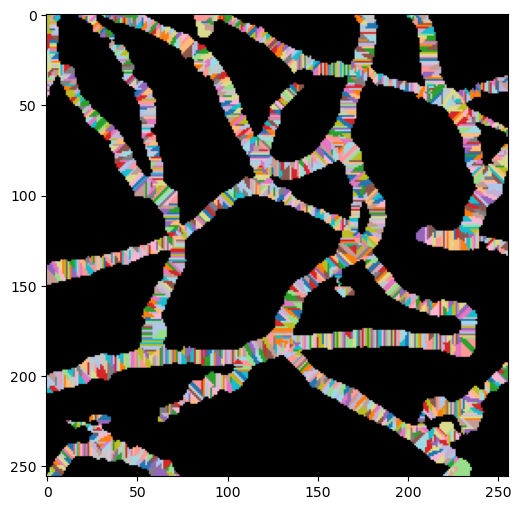

In [5]:
def show_indices(labeled_image):
    """Shuffle indices for better visualization."""
    unique_ids = np.unique(labeled_image)
    unique_ids_rand = np.random.permutation(range(1, len(unique_ids)))
    random_ids = np.concatenate(([0], unique_ids_rand))
    shuffled_map = random_ids[np.searchsorted(unique_ids, labeled_image)]

    cmap = plt.get_cmap("tab20").copy()
    cmap.set_under("black")

    plt.figure(figsize=(6, 6))
    plt.imshow(shuffled_map, cmap=cmap, vmin=1)

graph, labeled_image, id_cl_map = create_graph_with_mapping(skel_img, bin_img, length_threshold=10)

show_indices(labeled_image)

* `labeled_image` is an array containing indices (ids). 
* `id_cl_map` maps each id in `labeled_image` to a centerline pixel. The attributes are:

1. **edge**: A tuple (node1, node2, key) uniquely identifying an edge in a nx.MultiGraph
2. **abs_idx**: The index of the pixel in the `path` attribute of an edge to which this pixel is related
3. **outer_idx**: The index of the pixel in the outer path. It should be equal to `abs_idx - trim_amount[0]`
4. **coord**: The coordinate of the respective centerline pixel. It should be equal to `path[abs_idx]`

In [6]:
some_edge_data = list(id_cl_map.items())[9]
some_edge_data
# (id in labeled image, dict with edge data)

(10, {'edge': (1, 18, 0), 'abs_idx': 9, 'outer_idx': 9, 'coord': (9, 2)})

Instead of assigning foreground pixels to centerline pixels, the labeled image can be transformed to assign to graph edges instead:

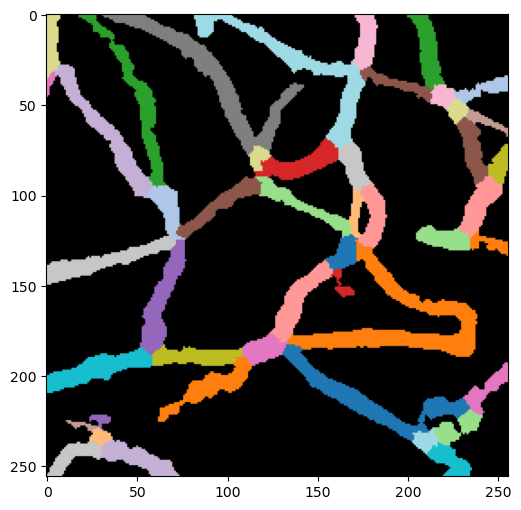

In [7]:
from pyvane.graph.util import map_centerline_labels_to_edges

labeled_elems, id_edge_map = map_centerline_labels_to_edges(labeled_image, id_cl_map)
show_indices(labeled_elems)

Instead of mapping to edges only, it is possible to also map foreground pixels to the closest junction node by setting `edges_only = False`. This creates "islands" at junction positions, that is, instead of foreground pixels mapping to inner paths, they map to the respective nodes. This also means that only outer paths are mapped to foreground pixels.

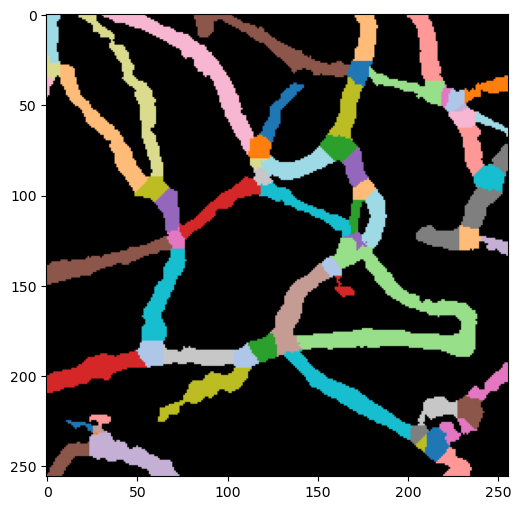

In [8]:
_, labeled_image_with_nodes, id_cl_map_outer, id_node_map = create_graph_with_mapping(
    skel_img, bin_img, length_threshold=10, edges_only = False)

labeled_elems_with_nodes, id_edge_map_outer = map_centerline_labels_to_edges(labeled_image_with_nodes, id_cl_map_outer)
show_indices(labeled_elems_with_nodes)

`id_node_map` maps each id to a node id in the graph:

In [9]:
list(id_node_map.items())[:5]
# (id in labeled image, node id in graph)

[(1, 17), (2, 18), (3, 26), (4, 29), (5, 30)]

## Extraction of vessel properties

Some built in PyVaNe properties:

In [10]:
from pyvane.graph.util import construct_attribute_volume
from pyvane.metrics import metrics

print(
    "Vessel density:", metrics.vessel_density(graph, img.shape),
    "\nBranch point density:", metrics.branch_point_density(graph, img.shape),
    "\nTortuosity:", metrics.tortuosity(graph, scale=5)
)

Vessel density: 0.03440716343842811 
Branch point density: 0.0003509521484375 
Tortuosity: 0.1838166756520884


Assignment of a radius value to each centerline pixel. Each edge will have a `radii` attribute with the same size as the respective `path` coordinates.

In [11]:
bin_img = labeled_image > 0
metrics.assign_centerline_radii(graph, bin_img)

An image can be constructed from a graph, the respective labeled volume, the id mapping and specific edge attribute:

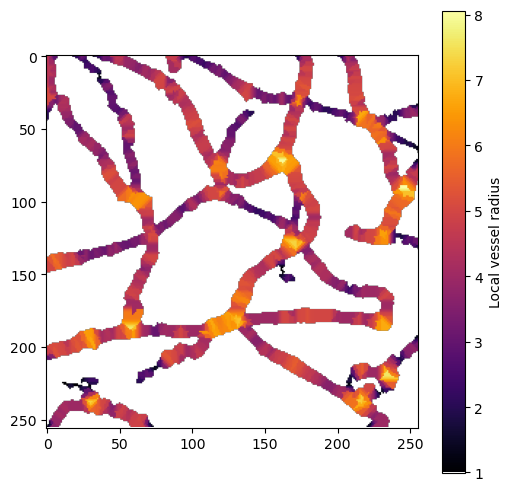

In [12]:
attribute_volume = construct_attribute_volume(
    graph, labeled_image, id_cl_map, edge_attr="radii")

plt.figure(figsize=(6, 6))
plt.imshow(attribute_volume, cmap="inferno")
plt.colorbar(label="Local vessel radius")

It is possible to create new edges or nodes attributes and map it to an image. The example below creates a mean_radius attribute for each edge.

In [13]:
for u, v, key, data in graph.edges(keys=True, data=True):
    radii = data["radii"]
    # Get outer path
    outer_start, outer_end = data["trim_amount"]
    radii = radii[outer_start:len(radii)-outer_end]

    if len(radii) > 0:
        mean_radius = np.mean(radii)
    else:
        # Assign node radius for robustness
        mean_radius = (graph.nodes[u]["radius"] + graph.nodes[v]["radius"]) / 2.0
    data["mean_radius"] = mean_radius

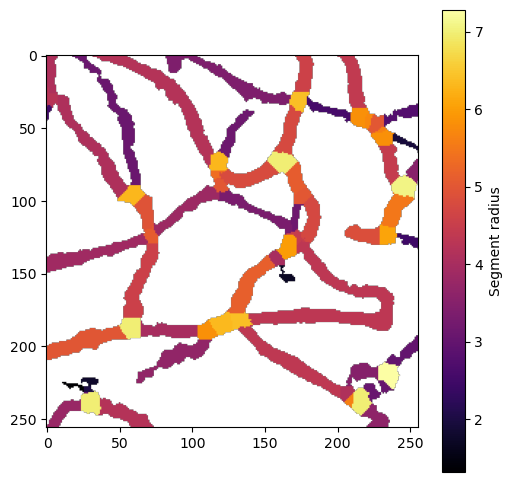

In [14]:
attribute_volume = construct_attribute_volume(
    graph, labeled_elems_with_nodes, id_edge_map_outer, edge_attr="mean_radius", id_node_map=id_node_map, node_attr="radius")

plt.figure(figsize=(6, 6))
plt.imshow(attribute_volume, cmap="inferno")
plt.colorbar(label="Segment radius")

## Fine-grained control of graph construction

The graph refinement process have many heuristics implemented. It is possible to tune all parameters and visualize intermediate steps by directly calling each individual function used for constructing the graph.

In [15]:
from pyvane.graph.creation import (
    assign_node_radii_and_outer_props,
    graph_from_skeleton,
    remove_clusters,
)
from pyvane.graph.refinement import refine_graph

length_threshold = 5.0

# Create initial graph that represents all skeleton pixels as accurately as possible
init_graph = graph_from_skeleton(skel_img)

# Remove clusters and degree-2 nodes to get a cleaner graph topology before refinement.
cond_graph = remove_clusters(init_graph)

# Refine the graph topology. Below are the default parameters used by the create_graph function.
# Please see the documentation of the refine_graph function for more details on the parameters 
# and their effects.
simple_graph, edt_bg, trash_paths = refine_graph(
    cond_graph, 
    bin_img,
    bulge_len_threshold = length_threshold,
    bulge_size_threshold = 0.0,
    bulge_ratio_threshold = 0.0,
    elongation_threshold = 0.0,
    multi_edge_threshold = length_threshold, 
    self_loop_threshold = length_threshold, 
    bridge_radius_ratio_threshold = 0.5,
    bridge_length_threshold = 3.0,
    collapse_length_ratio_threshold = 1.0,
    comp_size_threshold = 0, 
    comp_length_threshold = 1.0, 
    )

# This function needs to be called for generating the node radii and registering the final outer
# paths of the refined graph.
assign_node_radii_and_outer_props(simple_graph, edt_bg)